**Experiment 8: Demonstrate the working of Multi-layer perceptron with MLPClassifier() using Python programming.**

**Aim:** To demonstrate the working of a **Multi-Layer Perceptron (MLP)** using MLPClassifier() from the scikit-learn library in Python for solving a classification problem.

**Overview of Multi-Layer Perceptron (MLP)**

A **Multi-Layer Perceptron (MLP)** is a type of **artificial neural network** used for **classification and regression problems**.
It consists of multiple layers of neurons where each neuron is connected to neurons in the next layer.

An MLP typically contains:

* **Input Layer** – receives input features
* **Hidden Layer(s)** – performs computations and feature transformation
* **Output Layer** – produces the final prediction

MLPs learn patterns in data by adjusting **weights using backpropagation and gradient descent**.

---

**Key Components**

**1. Neuron (Perceptron)**

A neuron computes a weighted sum of inputs and applies an activation function.

z = Σ (w_i * x_i) + b

Where:

* (x_i) = input features
* (w_i) = weights
* (b) = bias
* (z) = linear combination

---

**2. Activation Function**

The activation function introduces **non-linearity** to the model.

Example (Sigmoid):

a = σ(z) = 1 / (1 + e^(-z))

Where

* (a) = neuron output
* (z) = weighted input

---

**3. Hidden Layers**

Hidden layers transform input data into **higher-level feature representations**.

a^(l) = f(W^(l) * a^(l-1) + b^(l))

Where

* (l) = layer number
* (W) = weight matrix
* (b) = bias
* (f) = activation function

---

**4. Loss Function**

Measures the difference between **predicted output and true output**.

Example (Binary Cross-Entropy):

L = - [y * log(ŷ) + (1 - y) * log(1 - ŷ)]

---

**5. Backpropagation**

Backpropagation updates weights using gradients to minimize the loss.

w_new = w_old - η * (∂L / ∂w)

Where

* (η) = learning rate
* (∂L / ∂w) = gradient of loss

---

**Key Terms**

**1. Weights**
Parameters that control the importance of each input.

**2. Bias**
A constant value added to the weighted sum to shift the activation.

**3. Activation Function**
Function that determines whether a neuron should be activated.

**4. Hidden Layer**
Intermediate layer that extracts complex patterns from data.

**5. Learning Rate**
Controls how much the weights change during training.

**6. Epoch**
One complete pass through the training dataset.

**7. Backpropagation**
Algorithm used to update weights by propagating error backward through the network.


**Mount Drive (Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Description – MNIST**

The MNIST dataset contains:

* 60,000 training images

* 10,000 testing images

* 28 × 28 grayscale handwritten digits

* 10 classes (0–9)

This is a multi-class classification problem .

**Dataset Loading and Inspection**

In [2]:
import numpy as np

X_train = np.load('drive/MyDrive/Datasets For ML/MNIST Handwritten Digits/train_images.npy')
Y_train = np.load('drive/MyDrive/Datasets For ML/MNIST Handwritten Digits/train_labels.npy')
X_test = np.load('drive/MyDrive/Datasets For ML/MNIST Handwritten Digits/test_images.npy')
Y_test = np.load('drive/MyDrive/Datasets For ML/MNIST Handwritten Digits/test_labels.npy')

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Unique Classes:", np.unique(Y_train))

Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)
Unique Classes: [0 1 2 3 4 5 6 7 8 9]


**Data Preprocessing**

MLP requires 2D input; therefore images must be flattened.

**1: Reshape (Flatten Images)**

In [3]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("After Flattening:", X_train.shape)

After Flattening: (60000, 784)


Each image is now represented as a 784-dimensional feature vector.

**2: Normalize Pixel Values**

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Normalization improves convergence and training stability.

**Model Building (Manual Hyperparameter Tuning)**

We manually tune:

| Parameter          | Purpose                            |
| ------------------ | ---------------------------------- |
| hidden_layer_sizes | Number of neurons in hidden layers |
| activation         | relu, tanh, logistic               |
| solver             | adam, sgd                          |
| alpha              | L2 regularization                  |
| learning_rate_init | Step size                          |
| max_iter           | Number of epochs                   |


**Model Implementation**

In [5]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=25,
    random_state=42,
    verbose=True
)

mlp.fit(X_train, Y_train)

Iteration 1, loss = 0.30460666
Iteration 2, loss = 0.11485417
Iteration 3, loss = 0.07722194
Iteration 4, loss = 0.05473532
Iteration 5, loss = 0.04032888
Iteration 6, loss = 0.03196042
Iteration 7, loss = 0.02499979
Iteration 8, loss = 0.01975731
Iteration 9, loss = 0.01617610
Iteration 10, loss = 0.01134879
Iteration 11, loss = 0.00984424
Iteration 12, loss = 0.01259514
Iteration 13, loss = 0.01064108
Iteration 14, loss = 0.01016730
Iteration 15, loss = 0.00751691
Iteration 16, loss = 0.00658504
Iteration 17, loss = 0.00424302
Iteration 18, loss = 0.00499201
Iteration 19, loss = 0.01061895
Iteration 20, loss = 0.00983189
Iteration 21, loss = 0.00552652
Iteration 22, loss = 0.00434423
Iteration 23, loss = 0.00634140
Iteration 24, loss = 0.00365180
Iteration 25, loss = 0.00534267


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=25, random_state=42,
              verbose=True)

**Network Architecture**

* Input Layer: 784 neurons

* Hidden Layer 1: 256 neurons (ReLU)

* Hidden Layer 2: 128 neurons (ReLU)

* Output Layer: 10 neurons (Softmax internally handled)

**Prediction Interpretation**

In [6]:
sample = X_test[0].reshape(1, -1)
prediction = mlp.predict(sample)
probs = mlp.predict_proba(sample)
print("Predicted digit:", prediction)
print("Class probabilities:", probs)

Predicted digit: [7]
Class probabilities: [[3.04680661e-15 1.70582341e-14 8.09059519e-14 6.56477706e-11
  1.16655277e-17 1.32867114e-15 2.06955539e-21 1.00000000e+00
  3.58362222e-16 1.66386741e-10]]


Interpretation:

* prediction gives the predicted digit.

* predict_proba() provides probability distribution over all 10 classes.

* The class with highest probability is selected as output.

**Inspecting Learned Weights**

In [7]:
print("Number of layers:", mlp.n_layers_)
print("Number of outputs:", mlp.n_outputs_)
print("Weight shapes:")
for w in mlp.coefs_:
    print(w.shape)

Number of layers: 4
Number of outputs: 10
Weight shapes:
(784, 256)
(256, 128)
(128, 10)


**Model Evaluation**

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

Accuracy: 0.9794

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



**Confusion Matrix**

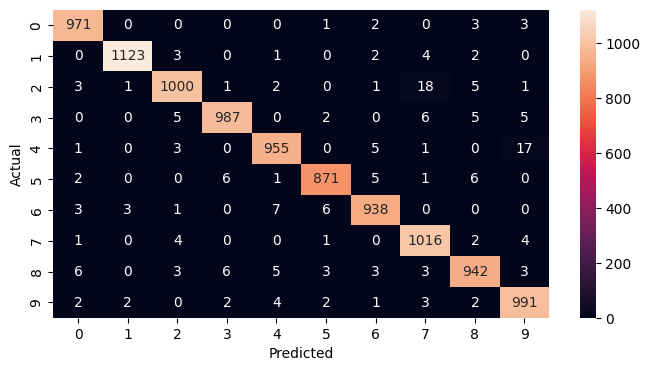

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Visualizing Misclassified Digits – MNIST (MLPClassifier)**

This section identifies and displays incorrectly classified test images from the MNIST dataset.

**1: Identify Misclassified Samples**

In [10]:
# Predict on test set
y_pred = mlp.predict(X_test)
# Find misclassified indices
misclassified_indices = np.where(y_pred != Y_test)[0]
print("Total Misclassified Samples:", len(misclassified_indices))

Total Misclassified Samples: 206


**2: Visualize Misclassified Images**

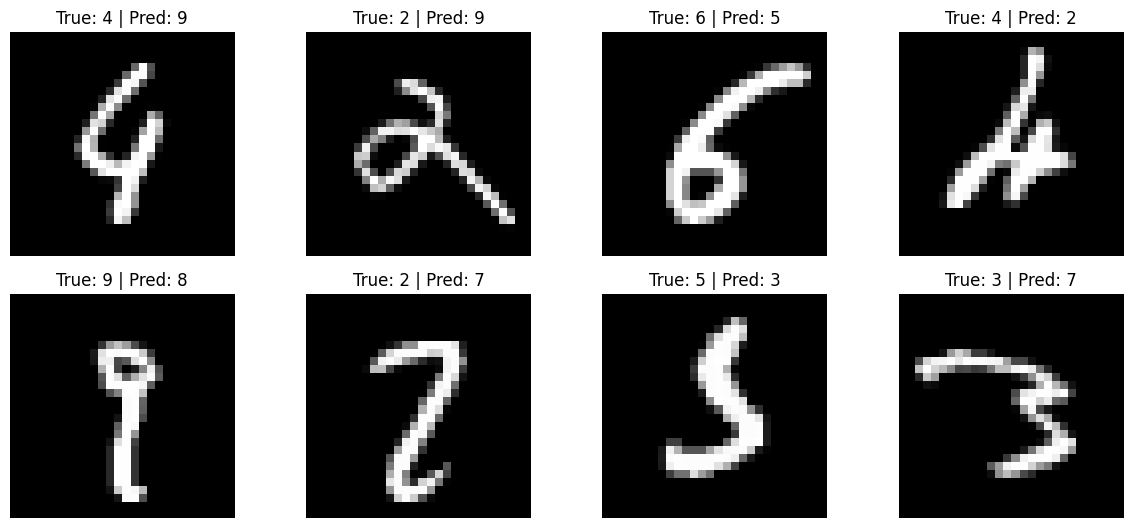

In [18]:
# Number of images to display
num_images = 8
plt.figure(figsize=(12,8))
for i in range(num_images):
    index = misclassified_indices[i]
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')
    plt.title(f"True: {Y_test[index]} | Pred: {y_pred[index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

**3: Analyze Prediction Confidence**

In [12]:
for i in range(3):
    index = misclassified_indices[i]
    probs = mlp.predict_proba(X_test[index].reshape(1,-1))
    print(f"\nSample Index: {index}")
    print("True Label:", Y_test[index])
    print("Predicted:", y_pred[index])
    print("Class Probabilities:", np.round(probs,3))


Sample Index: 115
True Label: 4
Predicted: 9
Class Probabilities: [[0.    0.    0.    0.    0.072 0.    0.    0.    0.    0.928]]

Sample Index: 149
True Label: 2
Predicted: 9
Class Probabilities: [[0.    0.    0.048 0.    0.    0.008 0.    0.    0.    0.943]]

Sample Index: 217
True Label: 6
Predicted: 5
Class Probabilities: [[0.    0.    0.    0.    0.    0.821 0.179 0.    0.    0.   ]]


This helps determine whether:

* The model was highly confident but incorrect.

* The model was uncertain between multiple classes.

**Summary**

| Component         | Description                |
| ----------------- | -------------------------- |
| Problem Type      | Multi-class Classification |
| Input Size        | 784                        |
| Output Size       | 10                         |
| Hidden Layers     | (256, 128)                 |
| Activation        | ReLU                       |
| Optimizer         | Adam                       |
| Loss Function              | Cross-Entropy              |
| Evaluation Metric | Accuracy                   |


**Conclusion**

The MLPClassifier successfully classifies MNIST handwritten digits using forward propagation and backpropagation. The network learns hierarchical representations from pixel intensities and achieves high accuracy after manual hyperparameter tuning.